In [5]:
import cv2, os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

PROCESSED = Path("../data/processed")

def scan_image(fpath):
    """Check one image. Returns dict of quality metrics."""
    result = {
        "path":      str(fpath),
        "split":     fpath.parts[-3],
        "label":     fpath.parts[-2],
        "corrupt":   False,
        "wrong_size":False,
        "too_dark":  False,
        "too_bright":False,
        "too_blurry":False,
        "height":    0,
        "width":     0,
        "mean_pixel":0,
        "blur_score":0,
    }
    img = cv2.imread(str(fpath))
    if img is None:
        result["corrupt"] = True
        return result

    h, w = img.shape[:2]
    result["height"] = h
    result["width"]  = w

    # Size check
    if (h, w) != (224, 224):
        result["wrong_size"] = True

    # Brightness check (mean pixel value 0–255)
    mean_val = img.mean()
    result["mean_pixel"] = round(mean_val, 1)
    if mean_val < 15:   result["too_dark"]   = True   # near black
    if mean_val > 240:  result["too_bright"] = True   # near white / overexposed

    # Blur check — Laplacian variance (higher = sharper)
    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    result["blur_score"] = round(blur_score, 1)
    if blur_score < 1.5:   result["too_blurry"] = True

    return result


# Scan everything (takes 15–30 min for ~150K images)
all_files = []
for split in ["train", "val", "test"]:
    for label in ["open", "closed"]:
        d = PROCESSED / split / label
        if d.exists():
            all_files += list(d.iterdir())

results = []
for fpath in tqdm(all_files, desc="Scanning images"):
    if fpath.suffix.lower() in {".jpg",".jpeg",".png"}:
        results.append(scan_image(fpath))

df_scan = pd.DataFrame(results)

# Save full report
os.makedirs("../outputs", exist_ok=True)
df_scan.to_csv("../outputs/quality_report.csv", index=False)
print(f"Scanned {len(df_scan):,} images. Report saved.")

# Print summary
issues = {
    "Corrupt files":     df_scan["corrupt"].sum(),
    "Wrong size":        df_scan["wrong_size"].sum(),
    "Too dark (< 15)":   df_scan["too_dark"].sum(),
    "Too bright (> 240)":df_scan["too_bright"].sum(),
    "Too blurry (< 1.5)": df_scan["too_blurry"].sum(),
}
print("\n── Quality issues found ─────────────────")
for name, count in issues.items():
    status = "✓ OK" if count == 0 else f"⚠ {count:,} files"
    print(f"  {name:25s}: {status}")

Scanning images: 100%|██████████| 126691/126691 [19:45<00:00, 106.90it/s]


Scanned 126,691 images. Report saved.

── Quality issues found ─────────────────
  Corrupt files            : ✓ OK
  Wrong size               : ✓ OK
  Too dark (< 15)          : ✓ OK
  Too bright (> 240)       : ✓ OK
  Too blurry (< 1.5)       : ⚠ 656 files


Total flagged: 12,532

Breakdown by dataset source:
source  label 
mrl     closed    5256
        open      7276


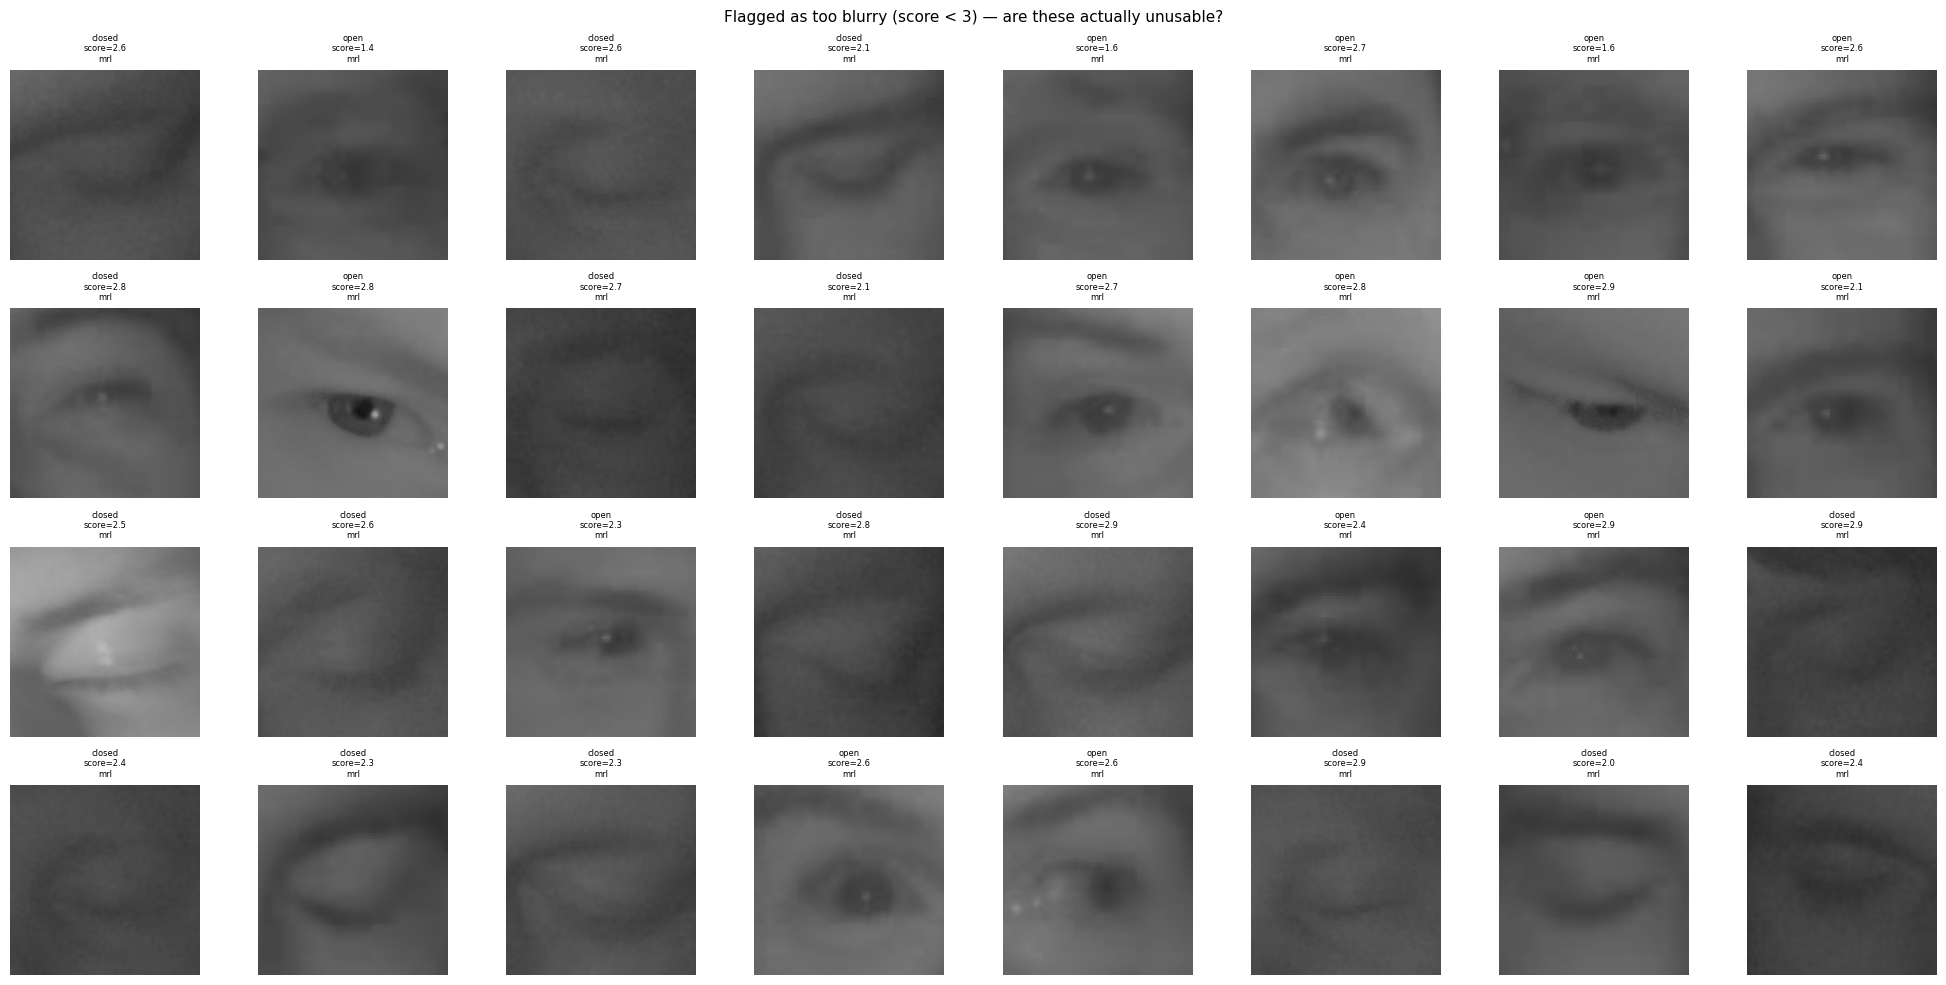

In [4]:
import cv2, random
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Load the report saved earlier
df = pd.read_csv("../outputs/quality_report.csv")

# Get the flagged blurry files
flagged = df[df["blur_score"] < 3].copy()
print(f"Total flagged: {len(flagged):,}")
print(f"\nBreakdown by dataset source:")
flagged["source"] = flagged["path"].apply(
    lambda p: "mrl" if "mrl_" in Path(p).name else "ddd"
)
print(flagged.groupby(["source", "label"])["path"].count().to_string())

# Show 32 random flagged images so you can judge them visually
sample = flagged.sample(min(32, len(flagged)), random_state=42)

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = cv2.imread(row["path"])
    if img is not None:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(
        f"{row['label']}\nscore={row['blur_score']:.1f}\n"
        f"{'mrl' if 'mrl_' in row['path'] else 'ddd'}",
        fontsize=6
    )
    ax.axis("off")

plt.suptitle(
    "Flagged as too blurry (score < 3) — are these actually unusable?",
    fontsize=11
)
plt.tight_layout()
plt.savefig("outputs/flagged_blurry_sample.png", dpi=120, bbox_inches="tight")
plt.show()

No corrupt images found — great!
No wrong_size images found — great!
No too_dark images found — great!


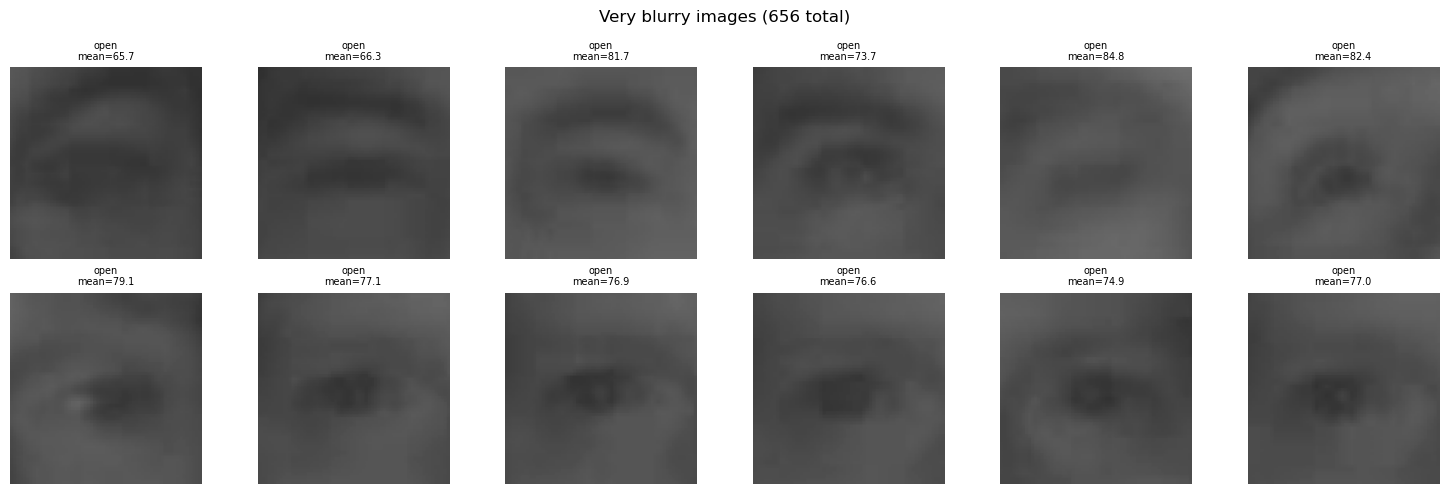

In [8]:
import matplotlib.pyplot as plt
import cv2

def show_flagged(df, flag_col, title, n=12):
    flagged = df[df[flag_col] == True].head(n)
    if len(flagged) == 0:
        print(f"No {flag_col} images found — great!")
        return
    cols = min(6, len(flagged))
    rows = (len(flagged) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
    if rows == 1: axes = [axes]
    for ax, (_, row) in zip(
            [a for row in axes for a in (row if hasattr(row,'__iter__') else [row])],
            flagged.iterrows()):
        img = cv2.imread(row["path"])
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{row['label']}\nmean={row['mean_pixel']}", fontsize=7)
        ax.axis("off")
    plt.suptitle(f"{title} ({len(df[df[flag_col]==True]):,} total)")
    plt.tight_layout(); plt.show()

# Show each type of problem image
show_flagged(df_scan, "corrupt",    "Corrupt images")
show_flagged(df_scan, "wrong_size", "Wrong size images")
show_flagged(df_scan, "too_dark",   "Too dark images")
show_flagged(df_scan, "too_blurry", "Very blurry images")

In [1]:
import pandas as pd
from pathlib import Path

# Load the saved report
df = pd.read_csv("../outputs/quality_report.csv")

# Files to remove — corrupt, wrong_size, AND too_blurry (score < 1.5)
to_remove = df[
    df["corrupt"] |
    df["wrong_size"] |
    (df["blur_score"] < 1.5)
]["path"].tolist()

print(f"Files to remove: {len(to_remove)}")
print(f"  Corrupt      : {df['corrupt'].sum()}")
print(f"  Wrong size   : {df['wrong_size'].sum()}")
print(f"  Too blurry   : {(df['blur_score'] < 1.5).sum()}")

# Safety check — never auto-delete more than 2% of dataset
total = len(df)
threshold_pct = int(total * 0.02)

if len(to_remove) > threshold_pct:
    print(f"\nWARNING: {len(to_remove)} files exceeds 2% safety limit ({threshold_pct}).")
    print("Review manually before proceeding.")
else:
    removed = 0
    missing = 0
    for path in to_remove:
        p = Path(path)
        if p.exists():
            p.unlink()
            removed += 1
        else:
            missing += 1

    print(f"\nDone!")
    print(f"  Removed : {removed} files")
    print(f"  Missing : {missing} files (already gone)")

    # Verify final counts
    print("\n── Final image counts ─────────────────────")
    base = Path("../data/processed")
    for split in ["train", "val", "test"]:
        for label in ["open", "closed"]:
            d = base / split / label
            n = len([f for f in d.iterdir() if f.is_file()]) if d.exists() else 0
            print(f"  {split:5s} / {label:6s} : {n:,}")

Files to remove: 524
  Corrupt      : 0
  Wrong size   : 0
  Too blurry   : 524

Done!
  Removed : 524 files
  Missing : 0 files (already gone)

── Final image counts ─────────────────────
  train / open   : 41,086
  train / closed : 42,961
  val   / open   : 10,457
  val   / closed : 10,600
  test  / open   : 10,464
  test  / closed : 10,599
